<a href="https://colab.research.google.com/github/ArushAlshi/HSIC-Lasso-Arrhythmia-Predictor/blob/main/HSIC_Lasso_Arrhythmia_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
pip install wfdb

Importing MIT-BIH Arrhythmia Database

In [85]:
import wfdb

In [86]:
record=wfdb.rdrecord('/content/drive/MyDrive/mit-bih-arrhythmia-database-1.0.0/100')

In [87]:
annotation=wfdb.rdann('/content/drive/MyDrive/mit-bih-arrhythmia-database-1.0.0/100','atr')

In [88]:
print(record.p_signal.shape)
print(record.fs)
print(record.sig_name)

(650000, 2)
360
['MLII', 'V5']


In [89]:
print(annotation.sample[:10])
print(annotation.symbol[:10])

[  18   77  370  662  946 1231 1515 1809 2044 2402]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


Plotting ECG Graph

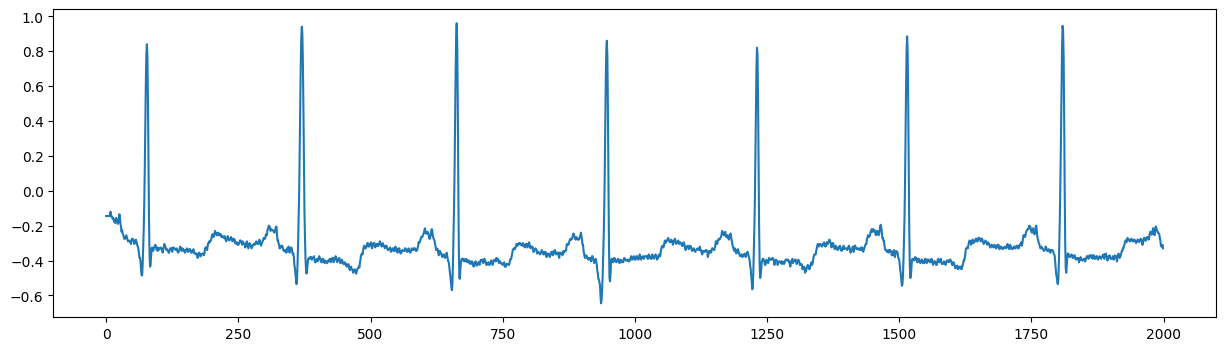

In [90]:
import matplotlib.pyplot as plt
mlii=record.p_signal[:,0]
plt.figure(figsize=(15,4))
plt.plot(mlii[:2000])
plt.show()

In [91]:
window = 180
beats = []
labels = []
for peak, sym in zip(annotation.sample, annotation.symbol):
  if sym=='+':
    continue
  start = peak - window
  end = peak + window
  if start < 0 or end > len(mlii):
    continue
  beats.append(mlii[start:end])
  labels.append(sym)

In [92]:
len(beats)
len(labels)

2271

In [93]:
beats[0].shape

(360,)

 Checking mean, std deviation, skewness, kurtosis for beats[0]Normal and beats[8]Arrhythmia

In [94]:
import numpy as np
from scipy import stats
mean=np.mean(beats[0])
std=np.std(beats[0])
skew=stats.skew(beats[0])
kurt=stats.kurtosis(beats[0])
print(std)
print(mean)
print(skew)
print(kurt)
mean_arrh=np.mean(beats[8])
std_arrh=np.std(beats[8])
skew_arrh=stats.skew(beats[8])
kurt_arrh=stats.kurtosis(beats[8])
print(std_arrh)
print(mean_arrh)
print(skew_arrh)
print(kurt_arrh)



0.16913102559685625
-0.30979166666666663
5.099974714582156
30.91398796888999
0.15001056997223583
-0.33390277777777777
5.714278044527954
38.72257365482531


Checking Zero Crossing around the mean to check the fluctuations

In [95]:
def zero_crossing_rate(window):
  window=window-np.mean(window)
  print("Sample values after centering:", window[:10])
  count=0
  for i in range(len(window)-1):
    if window[i]*window[i+1]<0:
      count+=1
  return count

zcr0=zero_crossing_rate(beats[0])
zcr8=zero_crossing_rate(beats[8])
print(zcr0, zcr8)

Sample values after centering: [-0.02520833 -0.03020833 -0.00520833  0.00979167  0.00979167  0.01979167
  0.01479167  0.01979167  0.02479167  0.03479167]
Sample values after centering: [-0.04609722 -0.02109722 -0.01609722 -0.02109722 -0.01609722 -0.00609722
  0.00390278  0.00890278  0.02890278  0.01390278]
34 22


Applying Mean, Std deviation, Skewness, Kurtosis to all 2271  samples

In [96]:
def extract_time_features(window):
  centered=window-np.mean(window)
  zc=0
  for i in range(len(centered)-1):
    if centered[i]*centered[i+1]<0:
      zc+=1
  return[
      np.mean(window),
      np.std(window),
      stats.skew(window),
      stats.kurtosis(window),
      zc
  ]

print(extract_time_features(beats[0]))

[np.float64(-0.30979166666666663), np.float64(0.16913102559685625), np.float64(5.099974714582156), np.float64(30.91398796888999), 34]


In [97]:
time_features=[]
for b in beats:
  time_features.append(extract_time_features(b))
time_features=np.array(time_features)
print(time_features.shape)

(2271, 5)


Checking fft_values, halfway point, magnitudes, ferqs, dominant freqs, spectral energy and spectral centroid

In [98]:
def extract_features(window, fs=360):
  window=window-np.mean(window)
  fft_vals=np.fft.fft(window)
  half=len(window)//2
  magnitudes=np.abs(fft_vals[:half])
  freqs=np.fft.fftfreq(len(window), d=1/fs)[:half]

  dominant_freq=freqs[np.argmax(magnitudes)]
  spectral_energy=np.sum(magnitudes**2)
  spectral_centroid=np.sum(freqs*magnitudes)/np.sum(magnitudes)

  return[dominant_freq, spectral_energy, spectral_centroid]
print(extract_features(beats[0]))



[np.float64(5.0), np.float64(1853.6065750000002), np.float64(20.7338918100625)]


Checking above features for all beats

In [99]:
freq_features=[]
for b in beats:
  freq_features.append(extract_features(b))
freq_features=np.array(freq_features)
print(freq_features.shape)


(2271, 3)


Printing both 2d arrays(2271,5) and (2271,3) in one single matrix

In [100]:
all_features=np.concatenate([time_features, freq_features], axis=1)
print(all_features.shape)
labels=np.array(labels)
print(labels.shape)

(2271, 8)
(2271,)


Checking number of Unique Labels


In [101]:
print(np.unique(labels))
print(len(np.unique(labels)))

['A' 'N' 'V']
3


Label encoding for A=0,N=1,V=2

In [102]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
labels_encoded=le.fit_transform(labels)
print(le.classes_)
print(labels_encoded[:10])

['A' 'N' 'V']
[1 1 1 1 1 1 0 1 1 1]


In [103]:
np.unique(labels_encoded, return_counts=True)

(array([0, 1, 2]), array([  33, 2237,    1]))

Applying the same for entry 200,208 and 210

1. Windowing Function

In [104]:

def process_record(record_id, window=180):
    record=wfdb.rdrecord(f'/content/drive/MyDrive/mit-bih-arrhythmia-database-1.0.0/{record_id}')
    annotation=wfdb.rdann(f'/content/drive/MyDrive/mit-bih-arrhythmia-database-1.0.0/{record_id}','atr')
    mlii = record.p_signal[:, 0]

    beats = []
    labels = []
    for peak, sym in zip(annotation.sample, annotation.symbol):
        if sym in ['+','~','|']:
            continue
        start = peak - window
        end = peak + window
        if start < 0 or end > len(mlii):
            continue
        beats.append(mlii[start:end])
        labels.append(sym)

    return beats, labels

2. Zero Center the Data

In [105]:
def extract_time_features(window):
    centered = window - np.mean(window)
    zc = 0
    for i in range(len(centered) - 1):
        if centered[i] * centered[i+1] < 0:
            zc += 1
    return [np.mean(window), np.std(window), stats.skew(window), stats.kurtosis(window), zc]

3. Frequency Domain Feature Extractor

In [106]:
def extract_freq_features(window, fs=360):
    window = window - np.mean(window)
    fft_vals = np.fft.fft(window)
    half = len(window) // 2
    magnitudes = np.abs(fft_vals[:half])
    freqs = np.fft.fftfreq(len(window), d=1/fs)[:half]
    dominant_freq = freqs[np.argmax(magnitudes)]
    spectral_energy = np.sum(magnitudes ** 2)
    spectral_centroid = np.sum(freqs * magnitudes) / np.sum(magnitudes)
    return [dominant_freq, spectral_energy, spectral_centroid]

4. Loop over Multiple Records

In [107]:
record_ids = ['100', '200', '208', '210']

all_beats = []
all_labels = []

for rid in record_ids:
    b, l = process_record(rid)
    all_beats.extend(b)
    all_labels.extend(l)

print("Total beats:", len(all_beats))

Total beats: 10472


In [108]:
keep_classes = ['N', 'V', 'F', 'A']

filtered_beats = []
filtered_labels = []

for b, l in zip(all_beats, all_labels):
    if l in keep_classes:
        filtered_beats.append(b)
        filtered_labels.append(l)

print(len(filtered_beats), len(filtered_labels))

all_beats = filtered_beats
all_labels = filtered_labels

10445 10445


5. Extract Features for every beat

In [109]:
time_features = np.array([extract_time_features(b) for b in all_beats])
freq_features = np.array([extract_freq_features(b) for b in all_beats])

all_features = np.concatenate([time_features, freq_features], axis=1)
print("Feature matrix shape:", all_features.shape)

Feature matrix shape: (10445, 8)


6. Encode Labels

In [110]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels_encoded = le.fit_transform(all_labels)

print(le.classes_)
print(np.unique(labels_encoded, return_counts=True))

['A' 'F' 'N' 'V']
(array([0, 1, 2, 3]), array([  63,  384, 7985, 2013]))


In [111]:
!pip install PyWavelets


In [112]:
import pywt
coeffs=pywt.wavedec(filtered_beats[0], 'db4', level=3)
print(len(coeffs))
for c in coeffs:
  print(c.shape)

4
(51,)
(51,)
(95,)
(183,)


Function for calculating Energies of the wavelets

In [113]:
import pywt
def wavelet_features(window, wavelet='db4', level=3):
  coeffs=pywt.wavedec(window,wavelet,level=level)
  energies=[np.sum(c**2) for c in coeffs]
  return energies

print(wavelet_features(filtered_beats[0]))


[np.float64(47.447665946383864), np.float64(2.232902759216582), np.float64(0.07362628232728877), np.float64(0.010178352097207789)]


Scale this to all beats

In [114]:
wavelet_feat_matrix=np.array([wavelet_features(b) for b in filtered_beats])
print(wavelet_feat_matrix.shape)

(10445, 4)


Combine everything into a final feature matrix

In [115]:
final_features=np.concatenate([all_features, wavelet_feat_matrix], axis=1)
print(final_features.shape)

(10445, 12)


Applying the HSIC-Lasso to the dataset

In [116]:
pip install pyHSICLasso

In [117]:
from pyHSICLasso import HSICLasso
hl=HSICLasso()
hl.input(final_features, labels_encoded)
hl.classification(num_feat=6)

print(hl.get_index())
print(hl.get_index_score())

Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Delta kernel for the outcomes.


/usr/local/lib/python3.13/dist-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 10445. Number of blocks 522.25 will be approximated to 522.
  warnings.warn(msg, RuntimeWarning)


[6, 2, 7, 9, 5, 0]
[0.5853652  0.12045352 0.06487134 0.00161809 0.00133779 0.00126574]


Data Preprocessing

In [118]:
from sklearn.model_selection import train_test_split
X_train_full, X_test_full, y_train, y_test = train_test_split(final_features, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded)
selected_idx=[6,2,7,9,5,0]
X_train_sel=X_train_full[:, selected_idx]
X_test_sel=X_test_full[:, selected_idx]

print(X_train_full.shape, X_test_full.shape)
print(X_train_sel.shape, X_test_sel.shape)

(8356, 12) (2089, 12)
(8356, 6) (2089, 6)


Applying Random Forest and SVM  

In [119]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
def train_and_evaluate(X_train, X_test, y_train, model_name):
  svm=SVC()
  svm.fit(X_train, y_train)
  svm_pred=svm.predict(X_test)
  print("SVM:")
  print(classification_report(y_test, svm_pred))

  rf=RandomForestClassifier(random_state=42, class_weight='balanced')
  rf.fit(X_train, y_train)
  rf_pred = rf.predict(X_test)
  print("Random Forest: ")
  print(classification_report(y_test, rf_pred))

  return svm_pred, rf_pred




svm_pred_full, rf_pred_full = train_and_evaluate(X_train_full, X_test_full, y_train, y_test)
svm_pred_sel, rf_pred_sel = train_and_evaluate(X_train_sel, X_test_sel, y_train, y_test)


SVM:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.00      0.00      0.00        77
           2       0.96      0.98      0.97      1597
           3       0.80      0.88      0.84       403

    accuracy                           0.92      2089
   macro avg       0.44      0.47      0.45      2089
weighted avg       0.88      0.92      0.90      2089



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest: 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.86      0.71      0.78        77
           2       0.98      0.99      0.98      1597
           3       0.94      0.95      0.94       403

    accuracy                           0.97      2089
   macro avg       0.69      0.66      0.68      2089
weighted avg       0.96      0.97      0.96      2089



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SVM:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.00      0.00      0.00        77
           2       0.96      0.98      0.97      1597
           3       0.80      0.88      0.84       403

    accuracy                           0.92      2089
   macro avg       0.44      0.47      0.45      2089
weighted avg       0.88      0.92      0.90      2089



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest: 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.84      0.75      0.79        77
           2       0.98      0.99      0.99      1597
           3       0.95      0.95      0.95       403

    accuracy                           0.97      2089
   macro avg       0.69      0.67      0.68      2089
weighted avg       0.96      0.97      0.97      2089



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix for Random Forest HSIC Lasso Selected features

<function matplotlib.pyplot.show(close=None, block=None)>

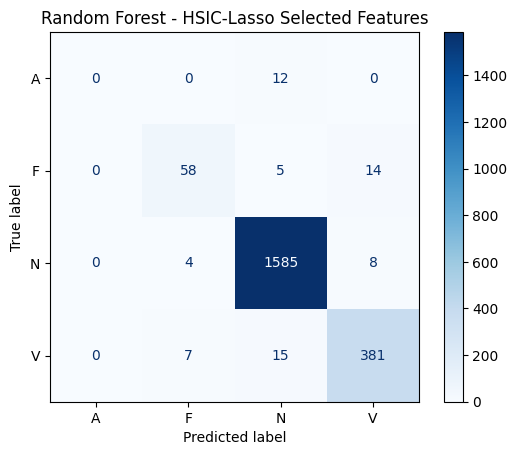

In [120]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred_sel)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Random Forest - HSIC-Lasso Selected Features')
plt.show

Confusion Matrix for SVM HSIC Lasso Selected features

<function matplotlib.pyplot.show(close=None, block=None)>

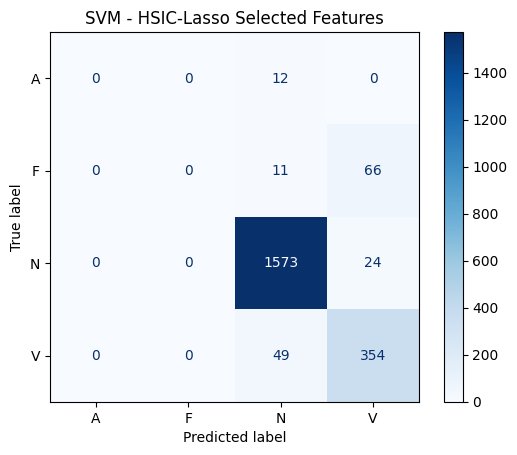

In [121]:
cm_svm = confusion_matrix(y_test, svm_pred_sel)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('SVM - HSIC-Lasso Selected Features')
plt.show